Machine Learning: Clasificar si un videojuego será popular o no basado en el rating conseguido de juegos de diferentes generos dentro de la plataforma Steam.

Este proyecto está enfocado en hacer el análisis de de los videojuegos mejor rankeados y recomendados en Steam, clasificandolos por género, precio y recomendaciones y así determinar si un juego puede ser considerado popular o no.

In [1]:
#Instalaciones
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [27]:
#Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import joblib

In [28]:
#Data set de Videojuegos de Steam

df = pd.read_csv("games.csv")

df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [29]:
#Columnas del Dataset

df.columns

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  object 
 1   Name                        122611 non-null  object 
 2   Release date                122611 non-null  object 
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image                122530 non-null  object 
 13  Website     

In [30]:
#Limpieza de columnas (Solo usaremos 4 porque hay campos vacios en la dataset)

df = df[['Name', 'Genres', 'Price', 'Recommendations']]

df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114198 entries, 496350 to 4141790
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Name             114198 non-null  object
 1   Genres           114198 non-null  object
 2   Price            114198 non-null  int64 
 3   Recommendations  114198 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 4.4+ MB


In [31]:
#Variable Popularidad

df['Popular'] = np.where(df['Recommendations']> 1000, 1, 0)
df['Popular'].value_counts()

,count
Popular,
0,107865
1,6333


In [32]:

#Dataset ya limpiado
df.head()

,Name,Genres,Price,Recommendations,Popular
496350,"Jul 29, 2016",Adventure,65,231,0
1034400,"May 6, 2019",Casual,0,0,0
3292190,"Oct 31, 2024","Casual,Indie,Simulation",0,0,0
3631080,"Apr 24, 2025","Action,Early Access",0,0,0
1654170,"Apr 5, 2023","Action,Adventure",0,0,0


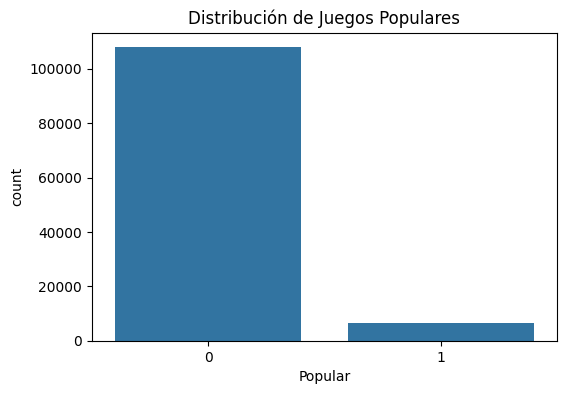

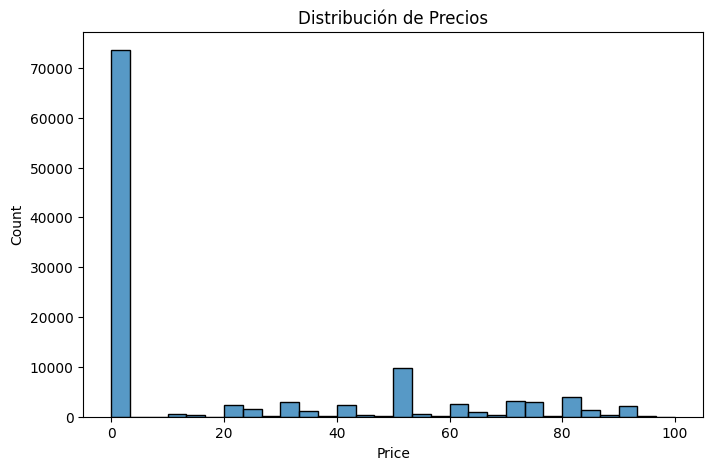

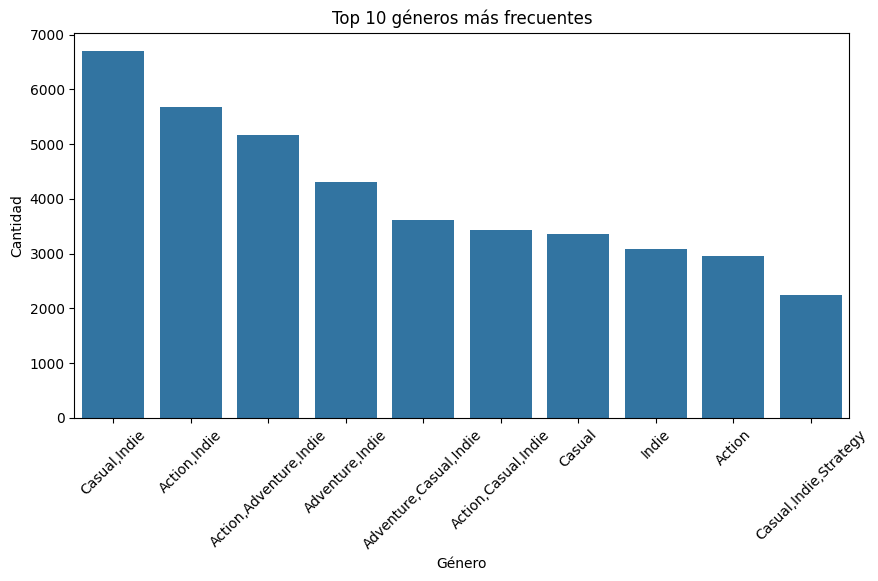

In [33]:
#Gráficos

#En este gráfico podemos visualizar el resultado conseguido entre los juegos que fueron considerados como Populares o no dentro del rango que hemos ingresado
plt.figure(figsize=(6,4))
sns.countplot(x='Popular',data=df)
plt.title("Distribución de Juegos Populares")
plt.show()

#En este gráfico podemos visualizar la tendencia de precios de videojuegos y deducir si hay algún tipo de relación entre el precio y su popularidad
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30)
plt.title("Distribución de Precios")
plt.show()

#En este gráfico veremos los 10 géneros más usados en la distribución de videojuegos para encontrar un patrón de genero más consumido a través de la plataforma.
top_genres=df['Genres'].value_counts().head(10)
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_genres.index,
    y=top_genres.values
)

plt.xticks(rotation=45)
plt.title("Top 10 géneros más frecuentes")
plt.xlabel("Género")
plt.ylabel("Cantidad")

plt.show()


In [34]:
#Pre-procesamiento

encoder= LabelEncoder()
df['Genres'] = encoder.fit_transform(df['Genres'])

In [35]:
#Variables

x= df[['Genres', 'Price', 'Recommendations']]
y= df['Popular']

In [36]:
#Training
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
#Modelo 1 (Precisión 99%)

  #Lógica
log_model = LogisticRegression()
log_model.fit(x_train,y_train)

log_pred = log_model.predict(x_test)

  #Métricas
print("Logistic Regression")
print ("Accuracy: ", accuracy_score(y_test, log_pred))

Logistic Regression
Accuracy:  0.9999562171628722


In [38]:
#Modelo 2 (Precisión 100%)

  #Lógica
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
rf_pred= rf_model.predict(x_test)

  #Métricas
print("Random Forest")
print("Accuracy: ", accuracy_score(y_test, rf_pred))

Random Forest
Accuracy:  1.0


In [39]:
#Guardar modelos

joblib.dump(rf_model, 'steam_model.pkl')
joblib.dump(encoder, 'genre_encoder.pkl')

['genre_encoder.pkl']